### [1] npy 파일 만들기

In [1]:
# 필요한 모듈 로딩
import os
import pyedflib
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.signal import butter, filtfilt
import random

In [ ]:
# 전처리 기본 설정값
EDF_ROOT = "D:/chb-mit-scalp-eeg-database-1.0.0/chb-mit-scalp-eeg-database-1.0.0"
RECORDS_WITH_SEIZURES = "./RECORDS-WITH-SEIZURES"
# (3) 채널 선택: 대표 채널 12개 선택
SELECTED_CHANNELS = [
    "FP1-F7", "F7-T7", "T7-P7", "P7-O1",
    "FP2-F8", "F8-T8", "T8-P8", "P8-O2",
    "FZ-CZ", "CZ-PZ",
    "FP1-F3", "FP2-F4"
]
TARGET_FS = 128           # (4) 다운샘플링: 128Hz로 변경
EPOCH_SEC = 2             # (6) 슬라이싱 설정: 2초 단위
SAMPLES_PER_EPOCH = TARGET_FS * EPOCH_SEC

SAVE_X_PATH = "./DATA/X.npy"    # X 저장 경로
SAVE_Y_PATH = "./DATA/y.npy"    # y 저장 경로
NORMAL_TARGET_COUNT = 15696     # 정상 신호 타겟 수
MAX_PER_FILE = 30               # 파일당 최대 샘플 수

In [ ]:
# (1) Bandpass Filtering (0.5–40Hz)
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=256, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

In [ ]:
# 발작 구간 (Seizure Interval) 추출용: summary.txt 파싱
def parse_seizure_summary(summary_path):
    seizure_ranges = []
    with open(summary_path, 'r') as f:
        lines = f.readlines()
    for i in range(len(lines)):
        if "Seizure Start Time" in lines[i]:
            start = int(lines[i].split(':')[-1].strip().split()[0])
            end = int(lines[i+1].split(':')[-1].strip().split()[0])
            seizure_ranges.append((start, end))
    return seizure_ranges

In [ ]:
# (6) 슬라이싱 + (7) 모델 입력 형태화 + (추가) Average Referencing
# 발작 구간 추출 (Seizure = 1)
def extract_seizure_segments(edf_path, summary_path, save_x, save_y):
    try:
        seizure_ranges = parse_seizure_summary(summary_path)
        f = pyedflib.EdfReader(edf_path)
        channel_labels = f.getSignalLabels()
        fs = f.getSampleFrequency(0)

        # (3) 채널 선택: 12개 채널만 사용
        available_channels = [ch for ch in SELECTED_CHANNELS if ch in channel_labels]
        valid_indices = [channel_labels.index(ch) for ch in available_channels]

        raw_signals = [f.readSignal(idx) for idx in valid_indices]
        duration = f.getFileDuration()

        for start, end in seizure_ranges:
            for sec in range(start, end - EPOCH_SEC):
                if sec + EPOCH_SEC > duration:
                    continue
                multi_segment = []
                for raw in raw_signals:
                    segment = raw[int(sec*fs):int((sec+EPOCH_SEC)*fs)]  # 2초 슬라이싱
                    if len(segment) != fs * EPOCH_SEC:
                        continue
                    segment = bandpass_filter(segment, fs=fs)          # (1) Bandpass Filtering
                    if fs != TARGET_FS:
                        segment = np.interp(                          # (4) 다운샘플링 (256Hz → 128Hz)
                            np.linspace(0, len(segment), TARGET_FS * EPOCH_SEC),
                            np.arange(len(segment)),
                            segment
                        )
                    multi_segment.append(segment)
                if len(multi_segment) == len(valid_indices):
                    multi_segment = np.array(multi_segment)
                    multi_segment -= np.mean(multi_segment, axis=0)   # (추가) Average Referencing (채널별 평균값 제거)
                    save_x.append(multi_segment)
                    save_y.append(1)                                  # 발작 = 1
        f.close()
    except:
        pass


In [ ]:
# (6) 슬라이싱 + (7) 모델 입력 형태화 + (추가) Average Referencing
# 정상 구간 추출 (Normal = 0)
def extract_normal_segments(edf_path, save_x, save_y, max_per_file=MAX_PER_FILE):
    try:
        f = pyedflib.EdfReader(edf_path)
        channel_labels = f.getSignalLabels()
        fs = f.getSampleFrequency(0)

        # (3) 채널 선택: 12개 채널만 사용
        available_channels = [ch for ch in SELECTED_CHANNELS if ch in channel_labels]
        valid_indices = [channel_labels.index(ch) for ch in available_channels]

        raw_signals = [f.readSignal(idx) for idx in valid_indices]
        duration = int(f.getFileDuration())

        candidates = list(range(0, duration - EPOCH_SEC))
        random.shuffle(candidates)
        count = 0

        for sec in candidates:
            multi_segment = []
            for raw in raw_signals:
                segment = raw[int(sec*fs):int((sec+EPOCH_SEC)*fs)]  # 2초 슬라이싱
                if len(segment) != fs * EPOCH_SEC:
                    continue
                segment = bandpass_filter(segment, fs=fs)          # (1) Bandpass Filtering
                if fs != TARGET_FS:
                    segment = np.interp(                          # (4) 다운샘플링 (256Hz → 128Hz)
                        np.linspace(0, len(segment), TARGET_FS * EPOCH_SEC),
                        np.arange(len(segment)),
                        segment
                    )
                multi_segment.append(segment)
            if len(multi_segment) == len(valid_indices):
                multi_segment = np.array(multi_segment)
                multi_segment -= np.mean(multi_segment, axis=0)   # (추가) Average Referencing
                save_x.append(multi_segment)
                save_y.append(0)                                  # 정상 = 0
                count += 1
                if count >= max_per_file:
                    break
        f.close()
    except:
        pass


In [ ]:
# 전체 데이터 처리 (발작 + 정상)
def process_all():
    with open(RECORDS_WITH_SEIZURES, 'r') as f:
        seizure_records = [line.strip() for line in f.readlines()]

    seizure_x, seizure_y = [], []
    normal_x, normal_y = [], []

    print("[1] Extracting Seizure Segments...")
    for record in tqdm(seizure_records, desc="Seizure Data"):
        parts = record.split('/')
        if len(parts) != 2:
            continue
        case, file = parts
        edf_path = os.path.join(EDF_ROOT, case, file)
        summary_path = os.path.join(EDF_ROOT, case, f"{case}-summary.txt")
        if os.path.exists(edf_path) and os.path.exists(summary_path):
            extract_seizure_segments(edf_path, summary_path, seizure_x, seizure_y)

    print("[2] Extracting Normal Segments...")
    edf_files = []
    for root, _, files in os.walk(EDF_ROOT):
        for file in files:
            if file.endswith(".edf"):
                rel_path = os.path.relpath(os.path.join(root, file), EDF_ROOT).replace("\\", "/")
                if rel_path not in seizure_records:
                    edf_files.append(os.path.join(root, file))

    for edf_path in tqdm(edf_files, desc="Normal Data"):
        extract_normal_segments(edf_path, normal_x, normal_y)
        if len(normal_x) >= NORMAL_TARGET_COUNT:
            break

    # 병합 후 저장
    X = np.array(seizure_x + normal_x)
    y = np.array(seizure_y + normal_y, dtype=np.int64)
    np.save(SAVE_X_PATH, X)
    np.save(SAVE_Y_PATH, y)
    print(f"\n✅ Saved EEG data to {SAVE_X_PATH} & {SAVE_Y_PATH}  ➜ Shape: {X.shape}, Labels: {np.bincount(y)}")


In [8]:
if __name__ == "__main__":
    os.makedirs("./DATA", exist_ok=True)
    process_all()

[1] Extracting Seizure Segments...


Seizure Data:   0%|          | 0/142 [00:00<?, ?it/s]

Seizure Data: 100%|██████████| 142/142 [07:59<00:00,  3.38s/it]


[2] Extracting Normal Segments...


Normal Data:  96%|█████████▌| 523/545 [38:33<01:37,  4.42s/it]  



✅ Saved EEG data to ./DATA/X.npy & ./DATA/y.npy  ➜ Shape: (30762, 12, 256), Labels: [15720 15042]


In [9]:
if __name__ == "__main__":
    # 채널 확인용 (1개만 확인해봄)
    for root, _, files in os.walk(EDF_ROOT):
        for file in files:
            if file.endswith(".edf"):
                path = os.path.join(root, file)
                f = pyedflib.EdfReader(path)
                print(f"{file} → {f.getSignalLabels()}")
                f.close()
                break

chb21_32.edf → ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', '-', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', '-', 'FZ-CZ', 'CZ-PZ', '-', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', '-', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', '-', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8']
chb16_13.edf → ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', '-', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', '-', 'FZ-CZ', 'CZ-PZ', '-', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', '-', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', '-', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8']
chb23_20.edf → ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8']
chb19_30.edf → ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', '-', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', '-', 'FZ-CZ', 'CZ-PZ', '-', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', '-', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', '-', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T

### [2] EDA

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
import koreanize_matplotlib

# 데이터 불러오기
X = np.load('./DATA/X.npy')  # shape: (31089, 12, 256)
y = np.load('./DATA/y.npy')  # shape: (31089,)

In [11]:
print(X.shape, y.shape)

(30762, 12, 256) (30762,)


- 라벨별 샘플 수 시각화

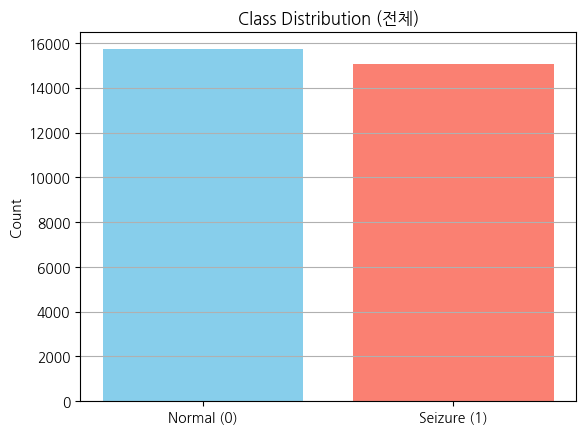

In [12]:
unique, counts = np.unique(y, return_counts=True)

plt.bar(["Normal (0)", "Seizure (1)"], counts, color=["skyblue", "salmon"])
plt.title("Class Distribution (전체)")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

- 시퀀스별 전체 평균 파형 비교

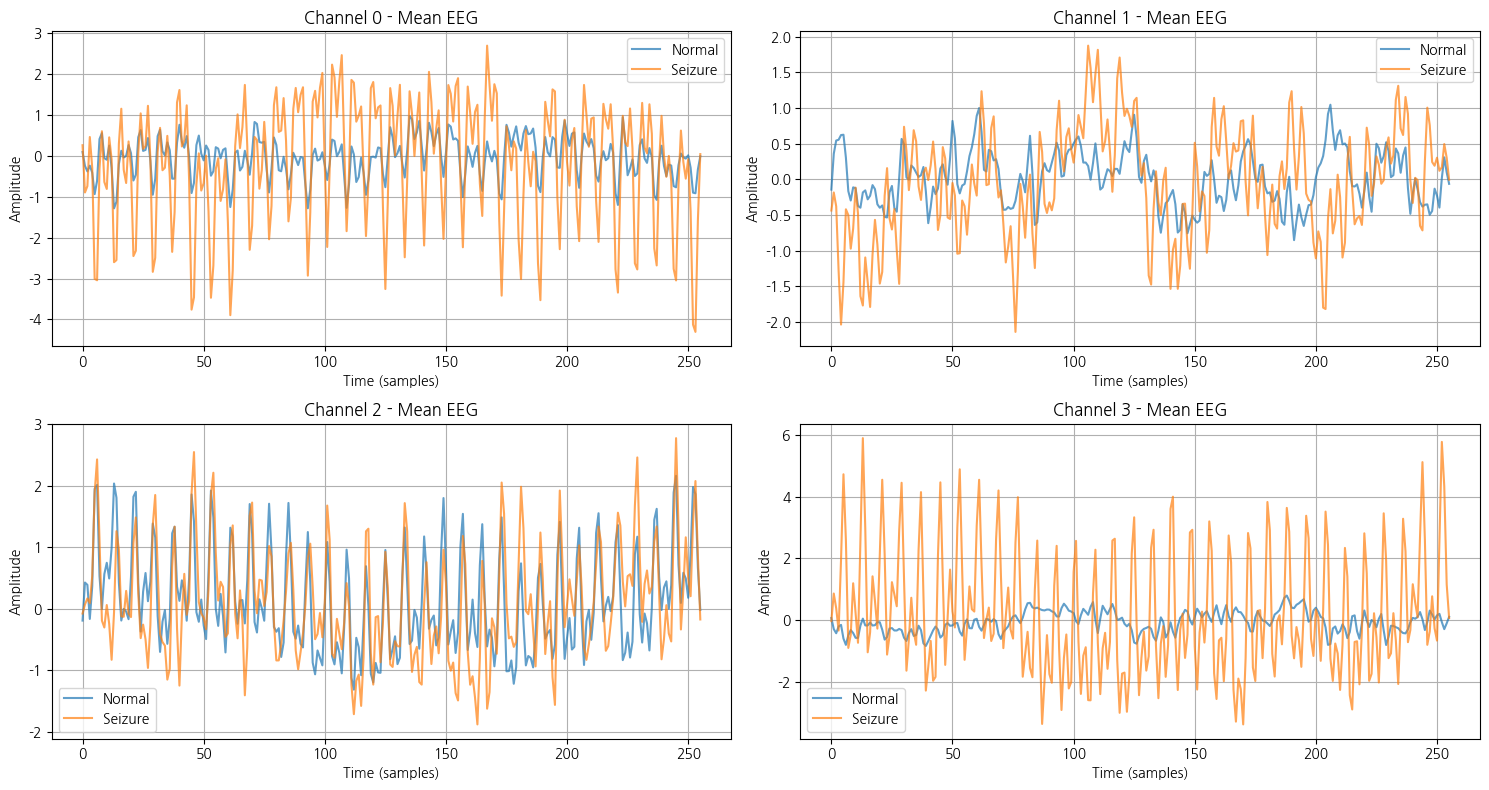

In [13]:
normal_mean = X[y == 0].mean(axis=0)  # shape: (12, 256)
seizure_mean = X[y == 1].mean(axis=0)

plt.figure(figsize=(15, 8))
for ch in range(4):  # 앞 4개 채널만 시각화
    plt.subplot(2, 2, ch+1)
    plt.plot(normal_mean[ch], label='Normal', alpha=0.7)
    plt.plot(seizure_mean[ch], label='Seizure', alpha=0.7)
    plt.title(f"Channel {ch} - Mean EEG")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

- 채널별 분산 비교

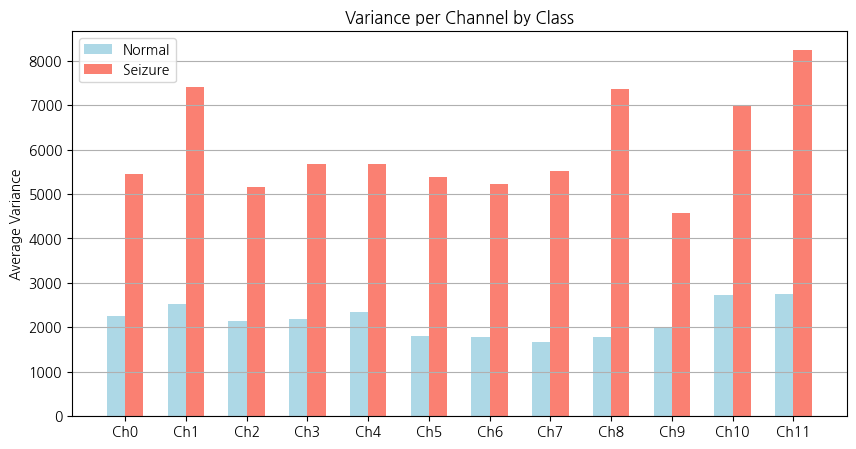

In [14]:
normal_var = X[y == 0].var(axis=0).mean(axis=1)  # 각 채널 평균 분산
seizure_var = X[y == 1].var(axis=0).mean(axis=1)

plt.figure(figsize=(10, 5))
channels = [f"Ch{i}" for i in range(12)]
x = np.arange(12)

plt.bar(x - 0.15, normal_var, width=0.3, label="Normal", color='lightblue')
plt.bar(x + 0.15, seizure_var, width=0.3, label="Seizure", color='salmon')

plt.xticks(x, channels)
plt.ylabel("Average Variance")
plt.title("Variance per Channel by Class")
plt.legend()
plt.grid(axis='y')
plt.show()

- 정상과 발작 신호 비교 시각화

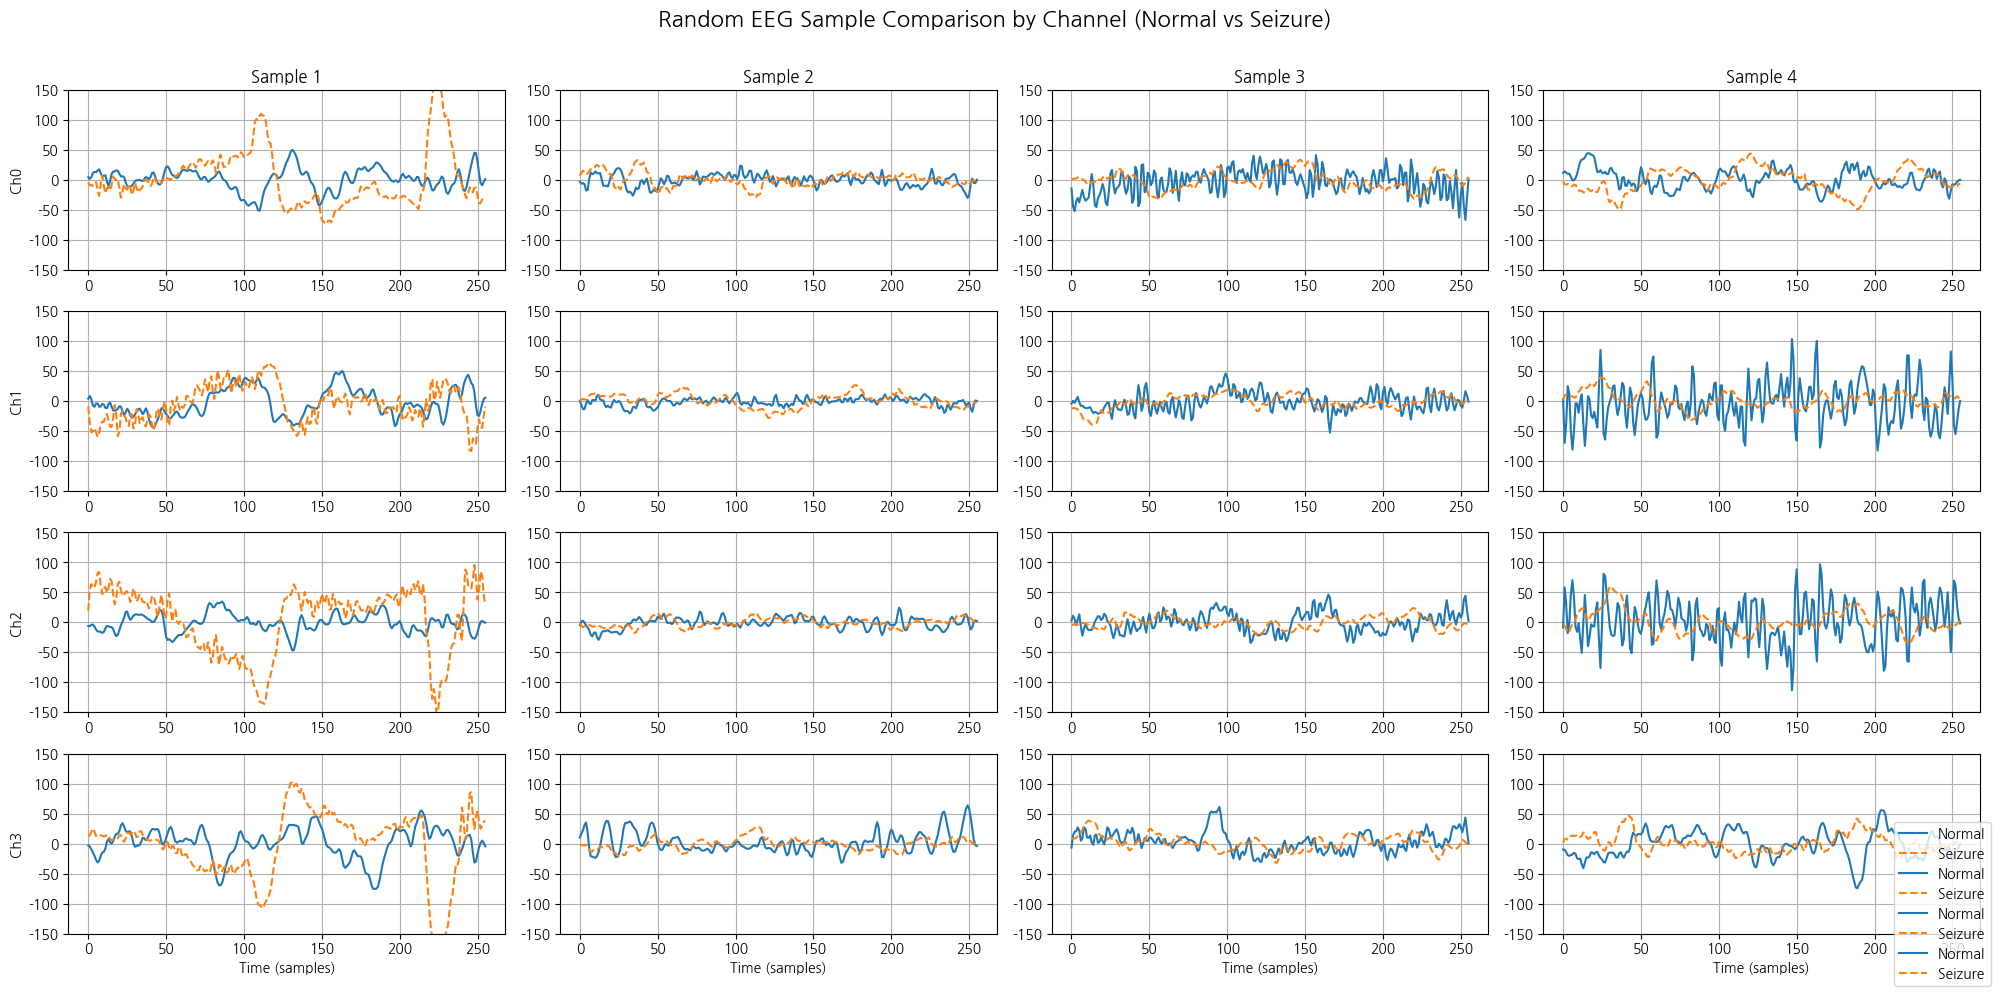

In [15]:
# 라벨별 인덱스 분리
normal_indices = np.where(y == 0)[0]
seizure_indices = np.where(y == 1)[0]

# 각각에서 4개 샘플 랜덤 추출
random.seed(42)
normal_samples = X[random.sample(list(normal_indices), 4)]
seizure_samples = X[random.sample(list(seizure_indices), 4)]

# 시각화: 4개 채널만 대표로 시각화
selected_channels = [0, 1, 2, 3]  # FP1-F7, F7-T7, T7-P7, P7-O1 (예시)

fig, axes = plt.subplots(4, 4, figsize=(20, 10))

for i in range(4):  # 4개 샘플
    for j, ch in enumerate(selected_channels):  # 4개 채널
        axes[j, i].plot(normal_samples[i][ch], label='Normal' if i == 0 else "")
        axes[j, i].plot(seizure_samples[i][ch], label='Seizure' if i == 0 else "", linestyle='--')
        if i == 0:
            axes[j, i].set_ylabel(f'Ch{ch}')
        axes[j, i].set_ylim(-150, 150)
        axes[j, i].grid(True)
        if j == 0:
            axes[j, i].set_title(f"Sample {i+1}")

for ax in axes[-1]:
    ax.set_xlabel("Time (samples)")

fig.suptitle("Random EEG Sample Comparison by Channel (Normal vs Seizure)", fontsize=16)
fig.legend(loc='lower right')
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

- bandpass 전후 시각화

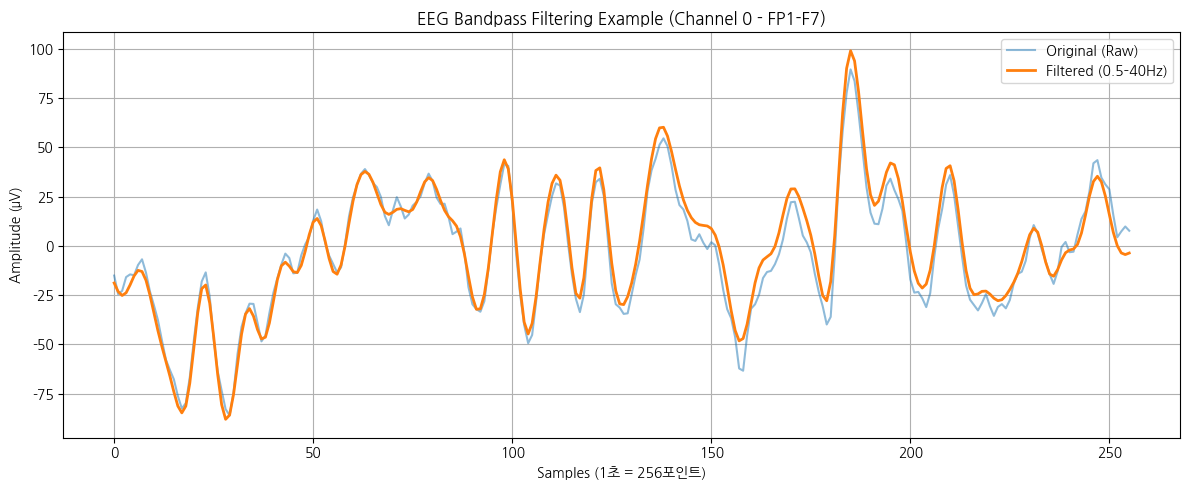

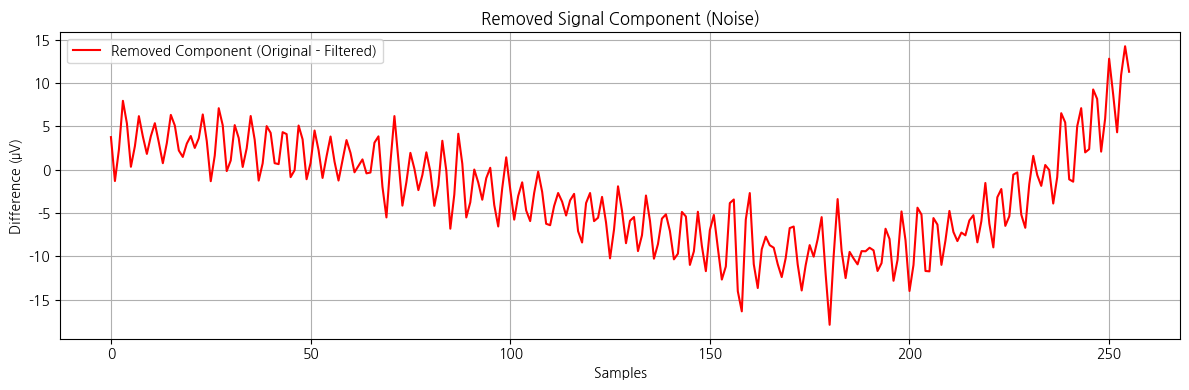

In [16]:
# 1개 샘플, 채널 하나 선택
sample = X[0]         # shape: (12, 256)
channel = sample[0]   # 예: FP1-F7 채널

# 필터 적용
filtered = bandpass_filter(channel, fs=256)

# 시각화 (필터 전/후)
plt.figure(figsize=(12, 5))
plt.plot(channel, label="Original (Raw)", alpha=0.5)
plt.plot(filtered, label="Filtered (0.5–40Hz)", linewidth=2)
plt.title("EEG Bandpass Filtering Example (Channel 0 - FP1-F7)")
plt.xlabel("Samples (1초 = 256포인트)")
plt.ylabel("Amplitude (μV)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 차이 시각화
difference = channel - filtered
plt.figure(figsize=(12, 4))
plt.plot(difference, color='red', label='Removed Component (Original - Filtered)')
plt.title("Removed Signal Component (Noise)")
plt.xlabel("Samples")
plt.ylabel("Difference (μV)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### [3] 데이터 분할

In [17]:
from sklearn.model_selection import train_test_split

# 저장 경로
save_dir = "./DATA"
os.makedirs(save_dir, exist_ok=True)

# 1차: Train (70%) / Temp (30%) 분할
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 2차: Temp → Validation (15%) / Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# 저장
np.save(os.path.join(save_dir, "multi_X_train.npy"), X_train)
np.save(os.path.join(save_dir, "multi_y_train.npy"), y_train)

np.save(os.path.join(save_dir, "multi_X_val.npy"), X_val)
np.save(os.path.join(save_dir, "multi_y_val.npy"), y_val)

np.save(os.path.join(save_dir, "multi_X_test.npy"), X_test)
np.save(os.path.join(save_dir, "multi_y_test.npy"), y_test)

print("🎉 Done splitting and saving!")
print(f"Train    : {X_train.shape}, {np.bincount(y_train)}")
print(f"Val      : {X_val.shape}, {np.bincount(y_val)}")
print(f"Test     : {X_test.shape}, {np.bincount(y_test)}")

🎉 Done splitting and saving!
Train    : (21533, 12, 256), [11004 10529]
Val      : (4614, 12, 256), [2358 2256]
Test     : (4615, 12, 256), [2358 2257]
